---
### 라이브러리 & 데이터 불러오기
---

In [44]:
import pandas as pd
import numpy as np
import isodate
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [169]:
# 영상정보
it_df = pd.read_csv('./data/results/it_instream_classified.csv')
fnb_df = pd.read_csv('./data/results/food_instream_classified.csv')

In [170]:
# 인스트림 먼저 제거
it_df = it_df[
    (it_df['adverdict']=='Low')|
    (it_df['adverdict'].isna())
]
len(it_df['adverdict'])

fnb_df = fnb_df[
    (fnb_df['adverdict']=='Low')|
    (fnb_df['adverdict'].isna())
]
len(fnb_df['adverdict'])

10177

---
### 전처리
---

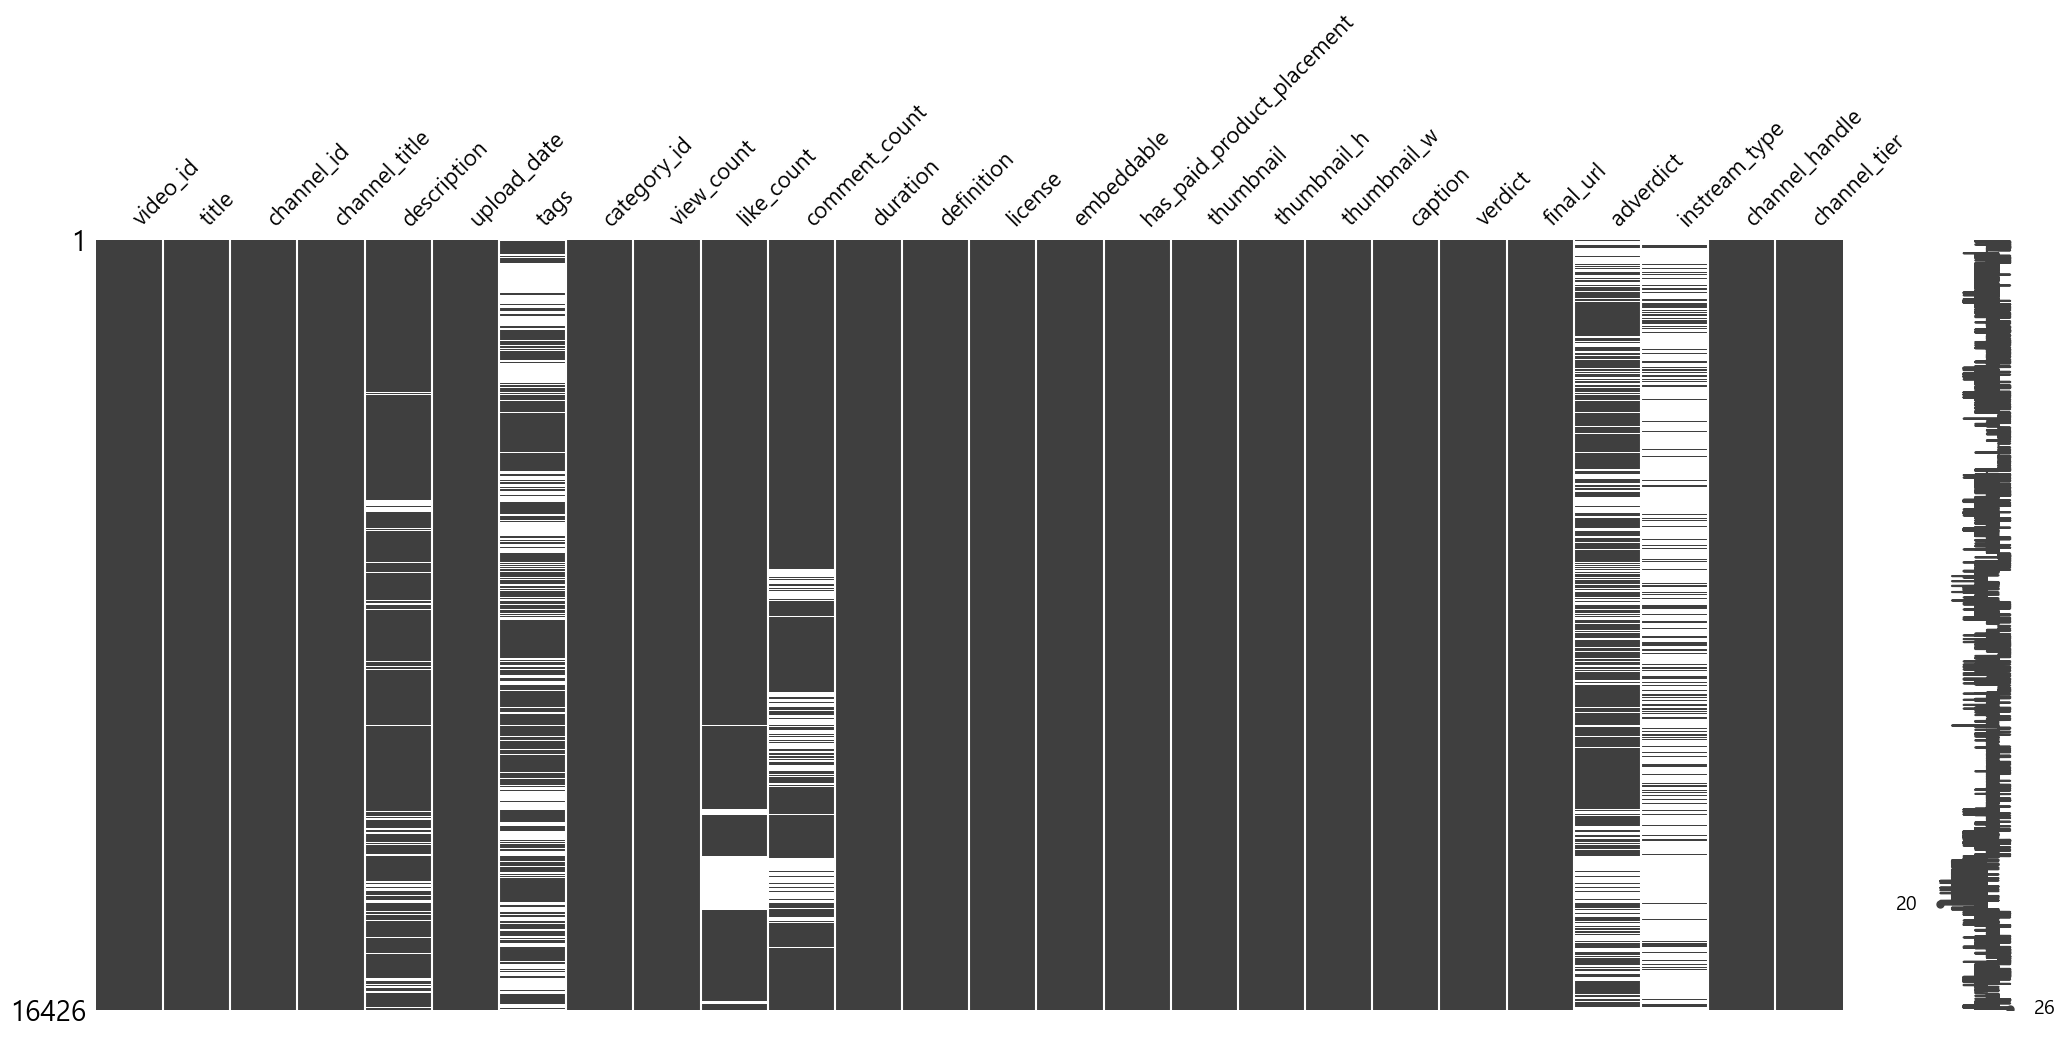

In [46]:
msno.matrix(it_df)
plt.show()

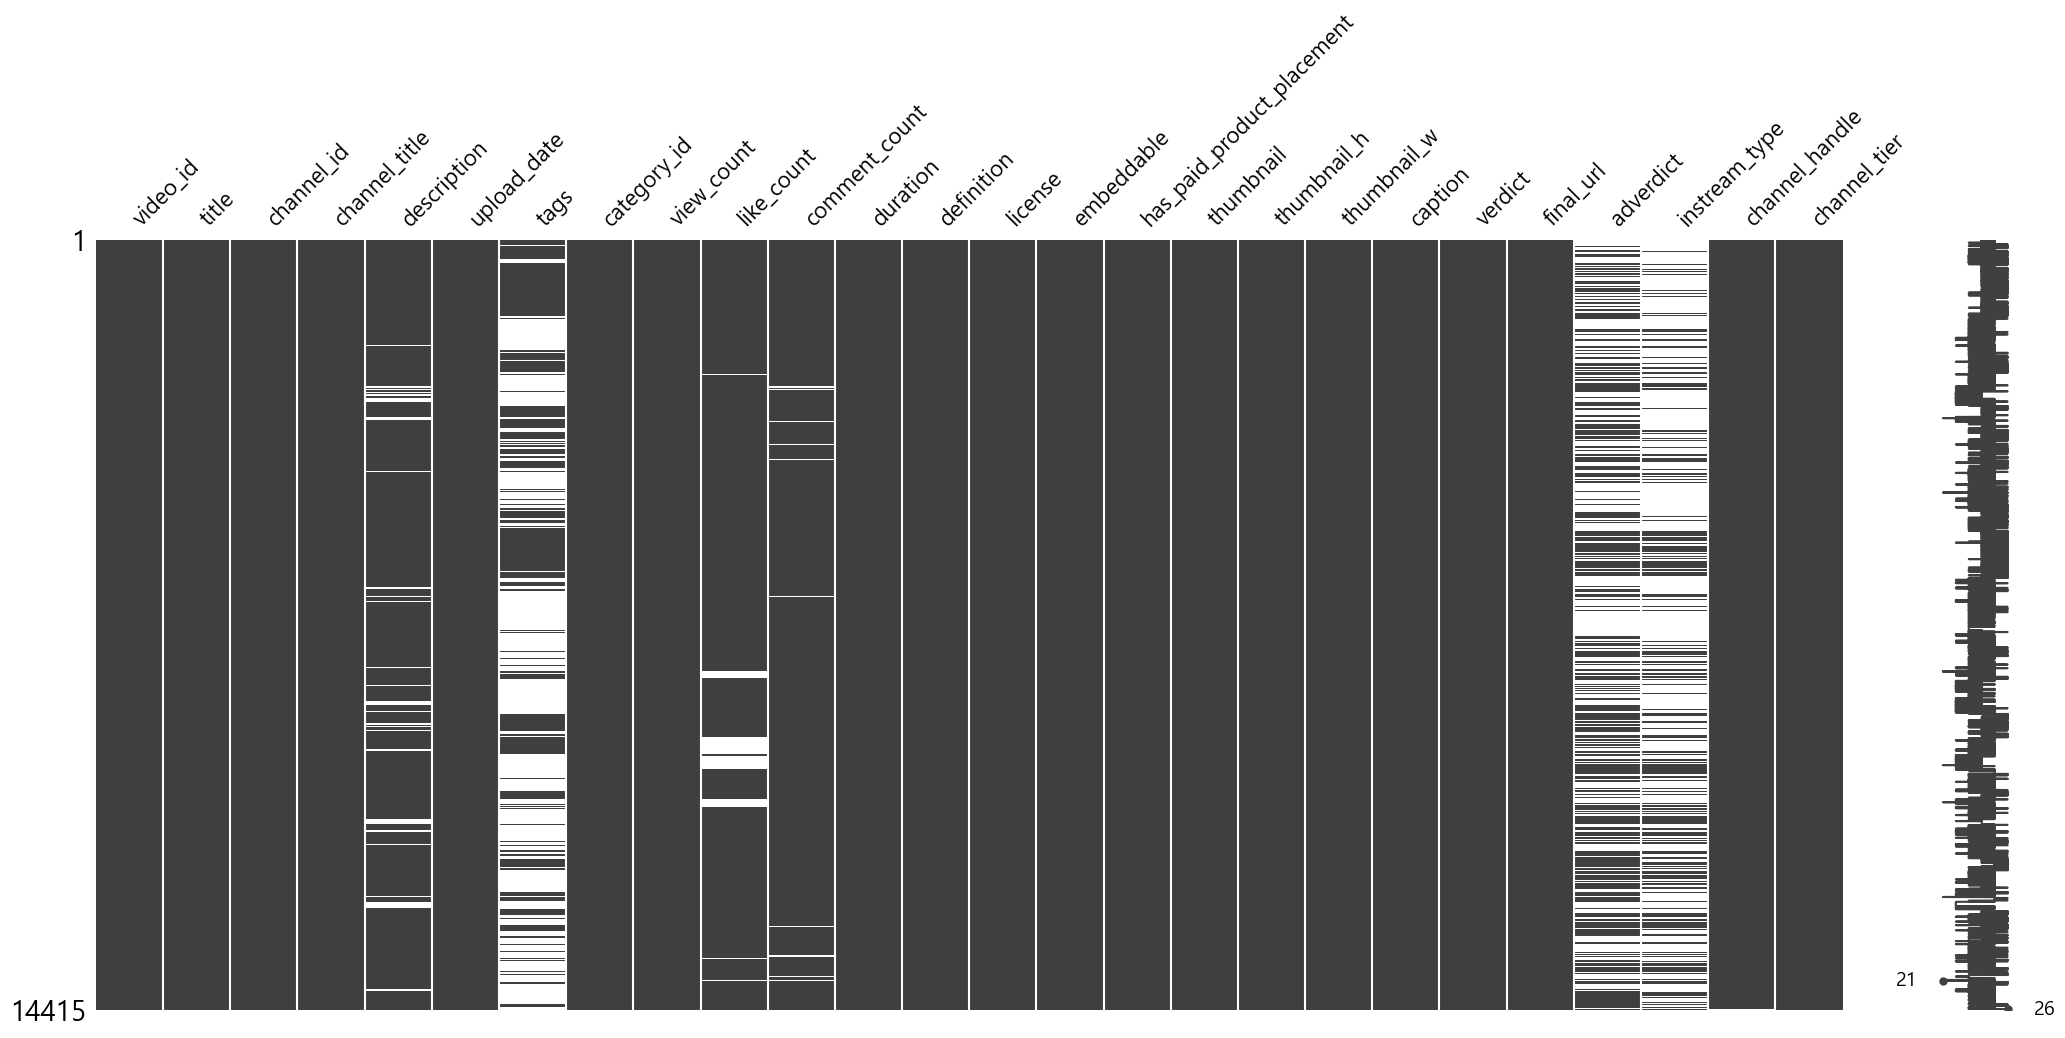

In [47]:
msno.matrix(fnb_df)
plt.show()

In [48]:
it_df.isna().sum()

video_id                          0
title                             0
channel_id                        0
channel_title                     0
description                    1155
upload_date                       0
tags                           6016
category_id                       0
view_count                        0
like_count                     1351
comment_count                  2557
duration                          0
definition                        0
license                           0
embeddable                        0
has_paid_product_placement        0
thumbnail                         0
thumbnail_h                       0
thumbnail_w                       0
caption                           0
verdict                           0
final_url                         0
adverdict                      4737
instream_type                 12913
channel_handle                    0
channel_tier                      0
dtype: int64

In [168]:
#===============================================================
# 전처리 함수(preprocessing)
# 
# [전처리 논리]
# 1. 결측치
#   1-1. like_count : 좋아요 수가 None인 경우는 영상 자체에서 좋아요 수를 공개하지 않은 것임. 우리의 성과지표인 참여도를 구할 수 없으므로 값을 제거
#   1-2. comment_count : 댓글 수가 None인 경우는 댓글을 비활성화 하여 댓글을 달 수 없게 막아둔 영상임. 고의로 댓글을 막은 것은 성과지표인 참여도가 중요하지 않은 영상으로 판단됨. -> 제거
#   1-3. description : 영상 설명이 None인 경우는 영상 설명을 작성하지 않은 것! ' ' 또는 '-'로 대체 필요. 대체 이전에 Flag를 만들어도 좋을 듯..! description_missing_flag(0,1)
#   1-4. tags : tags가 None인 경우는 tag를 넣지 않은 것! '-' 또는 ' '로 대체!. 대체 전에 Flag 를 만들어도 좋을 것 같음. tags_missing_flag (0,1)
#   1-5. adverdict : 영상이 instream 광고로 활용되었을 가능성 컬럼인데, None인 값은 쇼츠영상임! 'Shorts'로 대체해도 좋을 것 같음. (쇼츠 인스트림 광고는 쇼츠와 특성이 비슷하여 동일 선상에서 보기로 함.)
#   1-6. instream_type : None값의 의미는 instream이 아닌 값!
# 
# 2. 데이터 형변환
#   2-1. duration : iso 8601 형태는 직관성이 떨어지는 형태임. 초 단위로 바꿔서 직관성을 높임.
#   2-2. upload_date : str -> datetime 형태로 변환
#   2-3. 
#   
#===============================================================
def preprocessing(df):
    # -------------------------------
    # 1. 결측치 처리
    # -------------------------------
    # 1-1. like_count가 None인 값 제거
    df = df.dropna(subset=['like_count'])
    
    # 1-2. comment_count가 None인 값 제거
    df = df.dropna(subset=['comment_count'])
    
    # 1-3. description이 None인 값 '-'으로 대체
    df['description_missing_flag'] = df['description'].isna().astype(int)
    df['description'] = df['description'].fillna('-')
    
    # 1-4. tags None인 값 '-'로 대체
    df['tags_missing_flag'] = df['tags'].isna().astype(int)
    df['tags'] = df['tags'].fillna('-')
    
    # 1-5. adverdict None인 값 유지 or 'Shorts'로 대체
    df['adverdict'] = df['adverdict'].fillna('Shorts')
    
    # 1-6. instream_type이 None인 값 '일반영상'으로 대체
    df['instream_type'] = df['instream_type'].fillna('일반영상')
    
    # -------------------------------
    # 2. 데이터 형변환
    # -------------------------------
    # 2-1. duration 형태 변환 (iso 8601 -> seconds)
    df['duration'] = (
        df['duration']
        .apply(lambda x: isodate.parse_duration(x).total_seconds())
    )
    
    # 2-2. upload_date 형태 변환 (str -> datetime)
    df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce', utc=True)
    
    # 2-3. adverdict 라벨 변경
    adverdict_map = {
        'High' : 'Instream',
        'Low' : 'Normal',
        'Shorts' : 'Shorts'
    }
    
    df['adverdict'] = df['adverdict'].map(adverdict_map)
    
    # -------------------------------
    # 3. 파생지표 생성
    # -------------------------------
    # 3-1. 핵심성과지표: 참여도(Engagement_Rate)
    df['er'] = ((df['like_count'] + df['comment_count']) / df['view_count'].replace(0, float('nan'))) * 100
    
    # 3-2. 보조성과지표 1: 조회수 대비 좋아요(Likes_Engagement_Rate)
    df['ler'] = (df['like_count'])/(df['view_count'].replace(0, float('nan'))) * 100
    
    # 3-3. 보조성과지표 2: 조회수 대비 댓글 (Comments_Engagement_Rate)
    df['cer'] = (df['comment_count'])/(df['view_count'].replace(0, float('nan'))) * 100
    
    # 3-4. 보조성과지표 3: 가중 참여도 지수 (Weighted_Engagement_Index)
    df['wei'] = ((df['like_count'] + df['comment_count']*2) / df['view_count'].replace(0, float('nan'))) * 100
    
    # 3-5. 영상 설명 길이 (description_length)
    df['description_length'] = df['description'].apply(lambda x: 0 if x == '-' else len(str(x).split('|')))
    
    # 3-6. 카테고리명 (category_name)
    category_map = {
        1: "영화/애니메이션",
        2: "자동차",
        10: "음악",
        15: "반려동물",
        17: "스포츠",
        19: "여행/이벤트",
        20: "게임",
        22: "브이로그/라이프스타일",
        23: "코미디",
        24: "예능/오락 콘텐츠",
        25: "뉴스/정치",
        26: "정보형 콘텐츠(튜토리얼)",
        27: "교육",
        28: "과학/기술",
        29: "비영리/사회운동"
    }
    
    df['category_name'] = (df['category_id'].astype(int).map(category_map))
    
    # 3-7. 업로드 연도 (upload_year)
    df['upload_year'] = df['upload_date'].dt.year
    
    # 3-8. 업로드 월 (upload_month)
    df['upload_month'] = df['upload_date'].dt.month
    
    # 3-9. 업로드 요일 (upload_dayofweek)
    dayofweek_map = {
        0 : '월요일',
        1 : '화요일',
        2 : '수요일',
        3 : '목요일',
        4 : '금요일',
        5 : '토요일',
        6 : '일요일'
    }
    
    df['upload_dayofweek'] = (df['upload_date'].dt.dayofweek.astype(int).map(dayofweek_map))
    
    # 3-10. 업로드 시간대 (upload_hour)
    df['upload_hour'] = df['upload_date'].dt.hour
    
    # 3-11. 태그 개수 (tags_count)
    df['tags_count'] = df['tags'].apply(lambda x: len(x.split(',')) if x != '-' else 0)
    
    # 3-12. 업로드 분기
    df['upload_quarter'] = df['upload_date'].dt.quarter
    
    # 3-13. 년도+분기 (2023-Q1 형태)
    df['upload_ym_quarter'] = (
        df['upload_date'].dt.year.astype(str) + '-Q' +
        df['upload_date'].dt.quarter.astype(str)
    )
    
    # 3-14. 년도+날짜
    df['upload_ymd'] = df['upload_date'].dt.strftime('%Y-%m-%d')
    
    # # 3-15. 성공/실패 라벨링
    thresholds = (
    df.groupby('upload_ym_quarter')['er']
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: 'q25', 0.75: 'q75'})
    )
    
    df['q25'] = df['upload_ym_quarter'].map(thresholds['q25'])
    df['q75'] = df['upload_ym_quarter'].map(thresholds['q75'])
    df['grade'] = np.select(
        condlist=[
            df['er'] >= df['q75'],
            df['er'] <= df['q25'],
        ],
        choicelist=['성공', '실패'],
        default='보통'
    )
    
    # -------------------------------
    # 4. 행 제거
    # -------------------------------
    # 4-1. verdict가 error인 값 제거
    df = df[df['verdict'] != 'error']
    
    # -------------------------------
    # 5. 안쓰는 컬럼 버리기
    # -------------------------------
    df = df.drop(columns=['thumbnail_w', 'thumbnail_h', 'q25', 'q75', 'category_id'])
    
    return df

In [171]:
# 1. 전처리 먼저
it_df  = preprocessing(it_df)
fnb_df = preprocessing(fnb_df)

In [184]:
#========================================
# 데이터 전처리
#========================================
it_shorts_df   = it_df[it_df['verdict'] == 'shorts']
fnb_shorts_df  = fnb_df[fnb_df['verdict'] == 'shorts']
it_longform_df = it_df[it_df['verdict'] == 'longform']
fnb_longform_df = fnb_df[fnb_df['verdict'] == 'longform']

In [197]:
#=================================================================
# 필요없는 컬럼 제거
#=================================================================
data_group = [
    it_shorts_df,
    fnb_shorts_df,
    it_longform_df,
    fnb_longform_df
]

data_group = [df.drop(columns=['adverdict', 'verdict'], errors='ignore') for df in data_group]

# 언패킹
it_shorts_df, fnb_shorts_df, it_longform_df, fnb_longform_df = data_group

In [198]:
#===================================
# 데이터 뽑기
#===================================

# 1. 롱폼의 성공/실패 영상 분류하기 (썸네일 분석, 댓글 분석용)
it_longform_success_data = it_longform_df[it_longform_df['grade']=='성공']
it_longform_fail_data = it_longform_df[it_longform_df['grade']=='실패']
fnb_longform_success_data = fnb_longform_df[fnb_longform_df['grade']=='성공']
fnb_longform_fail_data = fnb_longform_df[fnb_longform_df['grade']=='실패']

# 2. 숏폼의 성공/실패 영상 분류하기
it_shorts_success_data = it_shorts_df[it_shorts_df['grade']=='성공']
it_shorts_fail_data = it_shorts_df[it_shorts_df['grade']=='실패']
fnb_shorts_success_data = fnb_shorts_df[fnb_shorts_df['grade']=='성공']
fnb_shorts_fail_data = fnb_shorts_df[fnb_shorts_df['grade']=='실패']



In [206]:
fnb_longform_fail_data['grade'].unique()

<ArrowStringArray>
['실패']
Length: 1, dtype: str

In [207]:
# 위 데이터 CSV로 추출
it_longform_success_data.to_csv('./data/results/preprocessed/it_longform_success_data.csv', encoding='utf-8-sig', index=False)
it_longform_fail_data.to_csv('./data/results/preprocessed/it_longform_fail_data.csv', encoding='utf-8-sig', index=False)
fnb_longform_success_data.to_csv('./data/results/preprocessed/fnb_longform_success_data.csv', encoding='utf-8-sig', index=False)
fnb_longform_fail_data.to_csv('./data/results/preprocessed/fnb_longform_fail_data.csv', encoding='utf-8-sig', index=False)

it_shorts_success_data.to_csv('./data/results/preprocessed/it_shorts_success_data.csv', encoding='utf-8-sig', index=False)
it_shorts_fail_data.to_csv('./data/results/preprocessed/it_shorts_fail_data.csv', encoding='utf-8-sig', index=False)
fnb_shorts_success_data.to_csv('./data/results/preprocessed/fnb_shorts_success_data.csv', encoding='utf-8-sig', index=False)
fnb_shorts_fail_data.to_csv('./data/results/preprocessed/fnb_shorts_fail_data.csv', encoding='utf-8-sig', index=False)

---
### EDA 시작
---

In [54]:
#================================================
# [인스트림 데이터 분리]
#================================================
it_normal = it_df[it_df['adverdict']!='Instream']
fnb_normal = fnb_df[fnb_df['adverdict']!='Instream']
it_shorts = it_df[it_df['verdict']=='shorts']

In [55]:
len(it_normal)
len(fnb_normal)

9678

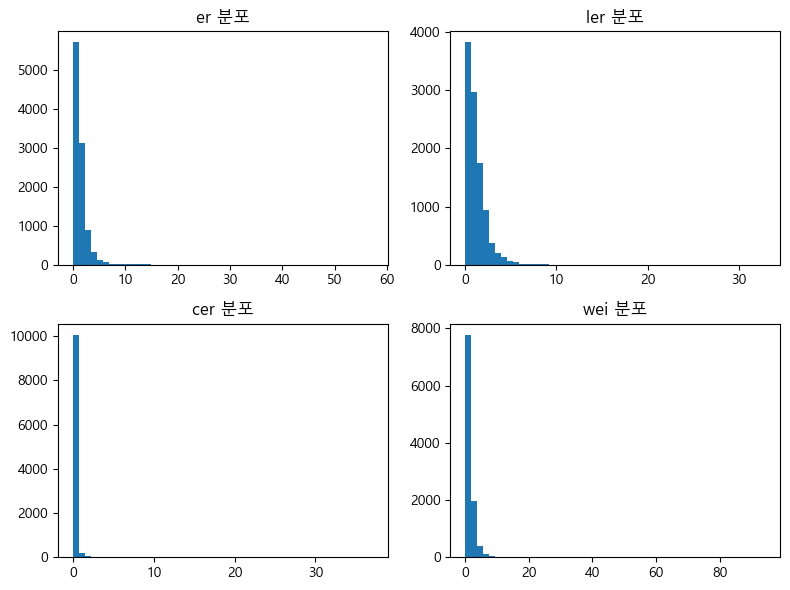

In [56]:
# er, ler, cer, wei 분포 — 극단적 우편향이므로 로그 스케일 병행
fig, axes = plt.subplots(2, 2, figsize=(8,6))
for ax, col in zip(axes.flatten(), ['er', 'ler', 'cer', 'wei']):
    ax.hist(it_normal[col], bins=50)
    ax.set_title(f'{col} 분포')
plt.tight_layout()
plt.show()

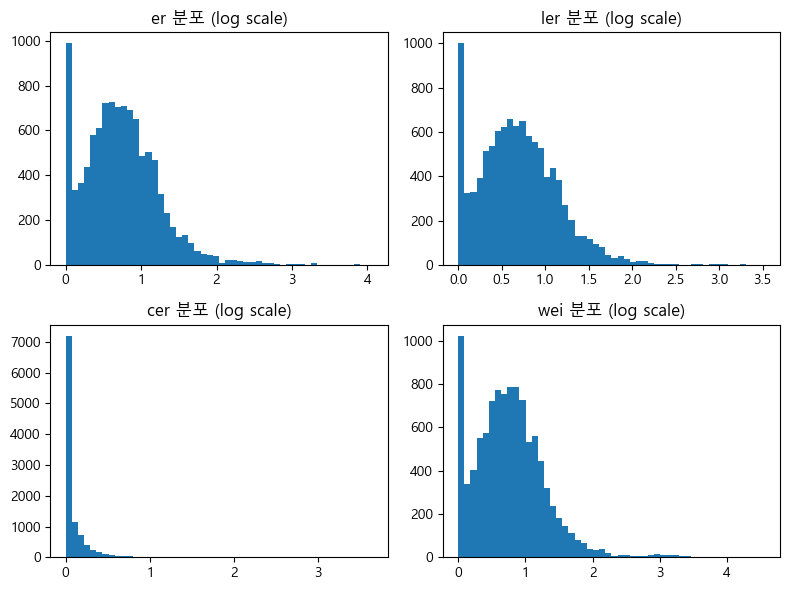

In [57]:
# er, ler, cer, wei 분포 — 극단적 우편향이므로 로그 스케일 병행
fig, axes = plt.subplots(2, 2, figsize=(8,6))
for ax, col in zip(axes.flatten(), ['er', 'ler', 'cer', 'wei']):
    ax.hist(np.log1p(it_normal[col]), bins=50)
    ax.set_title(f'{col} 분포 (log scale)')
plt.tight_layout()
plt.show()

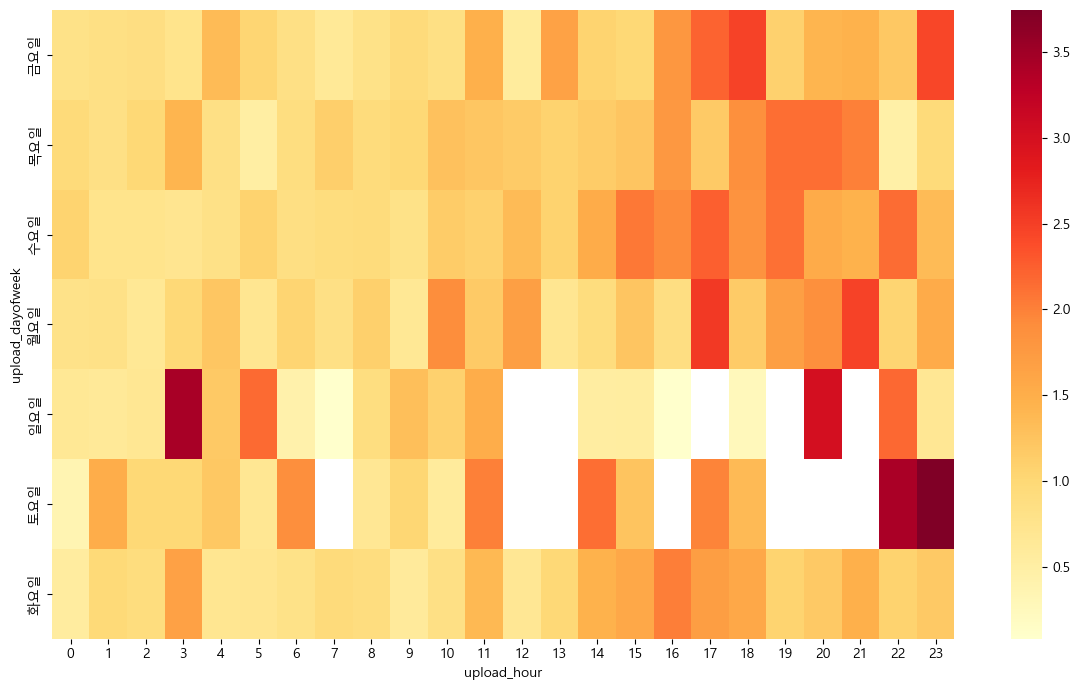

In [58]:
# 요일 × 시간대 피벗 히트맵
pivot = it_normal.groupby(['upload_dayofweek', 'upload_hour'])['er'].median().unstack()
plt.figure(figsize=(12,7))
sns.heatmap(pivot, annot=False, cmap='YlOrRd')
plt.tight_layout()
plt.show()

<Axes: xlabel='count', ylabel='category_name'>

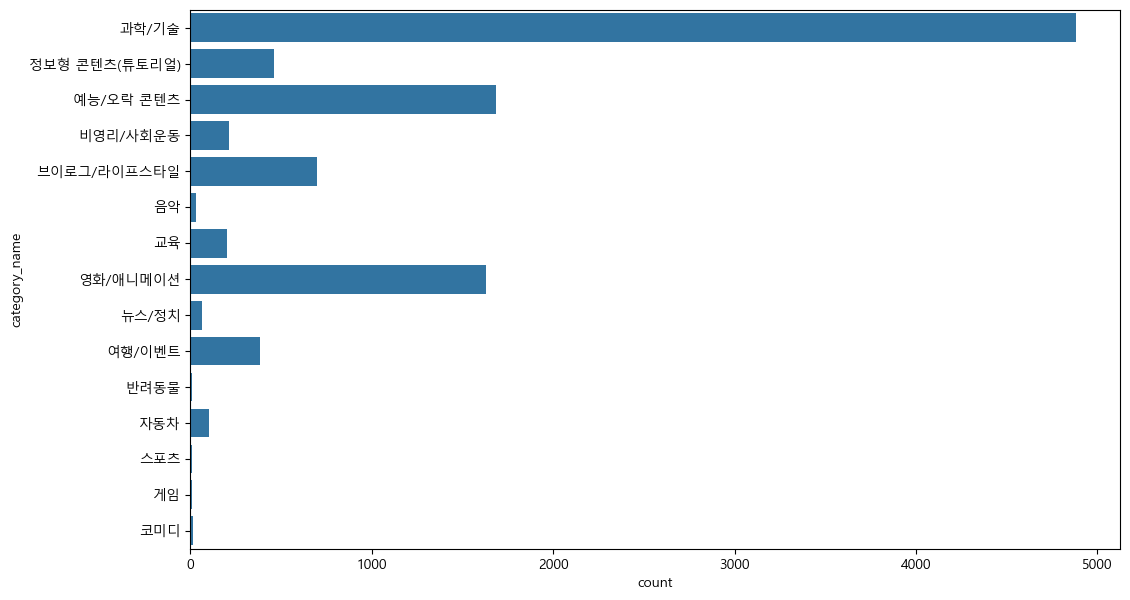

In [59]:
# 카테고리 분포 확인
plt.figure(figsize=(12,7))
sns.countplot(data=it_normal, y='category_name')

<Axes: xlabel='category_name', ylabel='er'>

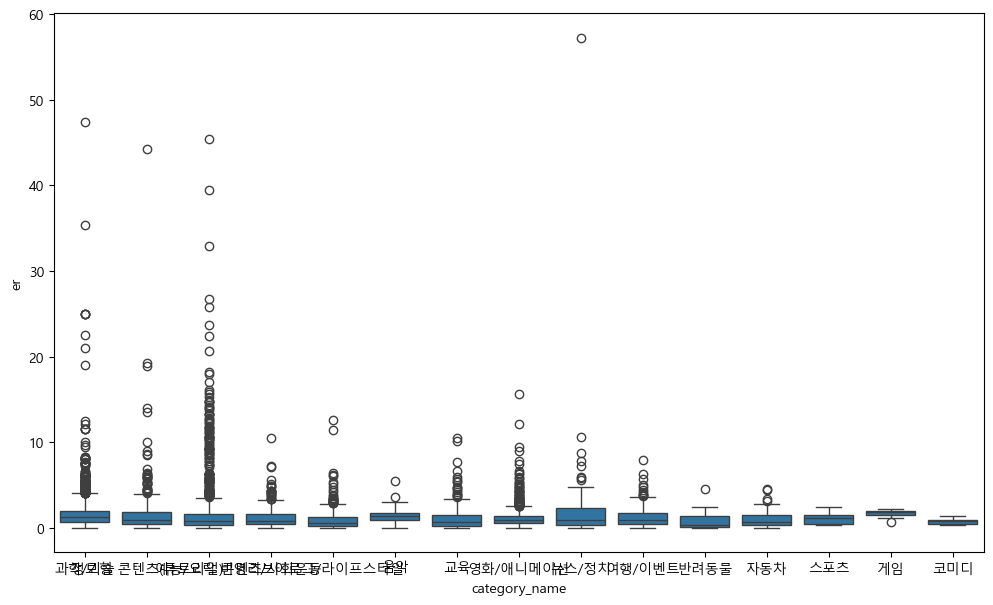

In [60]:
# 카테고리별 조회수 분포 확인
plt.figure(figsize=(12,7))
sns.boxplot(it_normal, x='category_name', y='er')

In [61]:
it_normal['er'].describe()

count    10390.000000
mean         1.418393
std          2.033361
min          0.000000
25%          0.477018
50%          1.010101
75%          1.771654
max         57.206955
Name: er, dtype: float64

In [62]:
it_normal.loc[it_normal['er']>50, 'thumbnail']

14812    https://i.ytimg.com/vi/Kp2rlS7Hoi8/hqdefault.jpg
Name: thumbnail, dtype: str

In [63]:
bins = [0, 60, 180, 600, 99999]
labels = ['Shorts', '단편', '중편', '장편']
it_normal['duration_type'] = pd.cut(it_normal['duration'], bins=bins, labels=labels)

it_normal.groupby('duration_type')['er'].median()

duration_type
Shorts    0.866862
단편        0.961538
중편        0.991609
장편        1.247772
Name: er, dtype: float64

<Axes: >

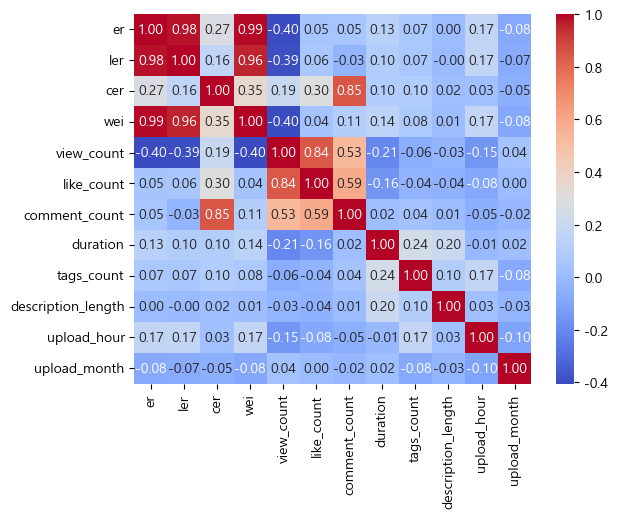

In [64]:
num_cols = ['er', 'ler', 'cer', 'wei', 'view_count', 'like_count',
            'comment_count', 'duration', 'tags_count', 'description_length',
            'upload_hour', 'upload_month']

sns.heatmap(it_normal[num_cols].corr(method='spearman'), annot=True, fmt='.2f', cmap='coolwarm')
# 비정규 분포이므로 pearson보다 spearman 권장

C:\Users\gmltk\AppData\Local\Temp\ipykernel_35812\2666589116.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(quarter_stats['upload_ym_quarter'], rotation=45, ha='right')


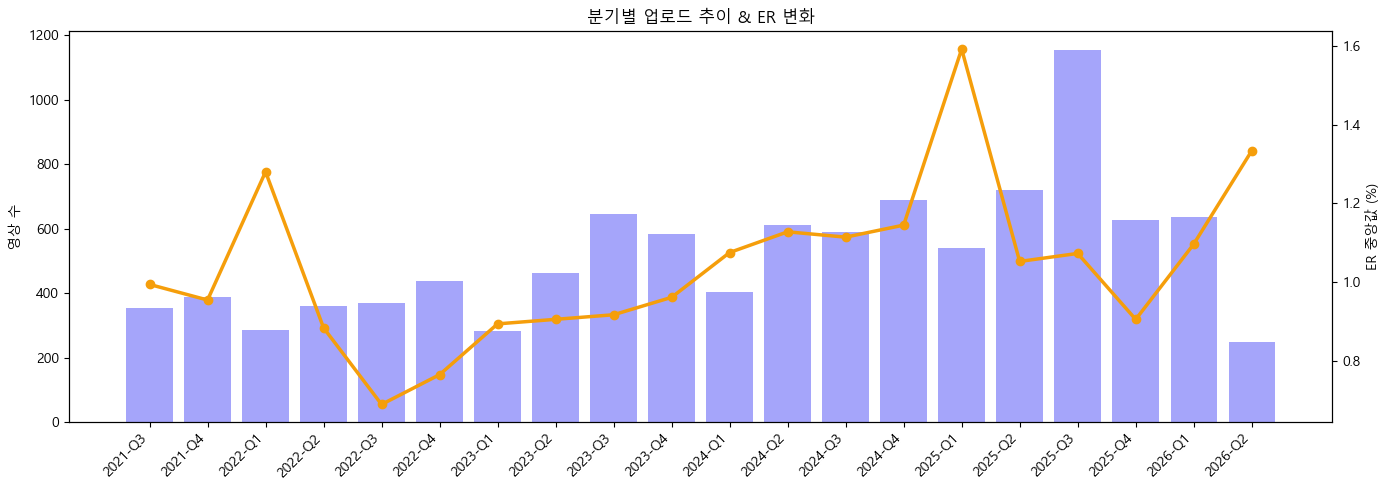

In [65]:
quarter_stats = (
    it_normal.groupby('upload_ym_quarter')
    .agg(
        영상수   = ('video_id', 'count'),
        ER중앙값 = ('er', 'median'),
        조회수   = ('view_count', 'median'),
    )
    .reset_index()
    .sort_values('upload_ym_quarter')  # 시간순 정렬
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(quarter_stats['upload_ym_quarter'], quarter_stats['영상수'],
        color='#5b5bf6', alpha=0.55, label='업로드 영상 수')
ax2.plot(quarter_stats['upload_ym_quarter'], quarter_stats['ER중앙값'],
         color='#f59e0b', linewidth=2.5, marker='o', label='ER 중앙값')

ax1.set_xticklabels(quarter_stats['upload_ym_quarter'], rotation=45, ha='right')
ax1.set_ylabel('영상 수')
ax2.set_ylabel('ER 중앙값 (%)')
plt.title('분기별 업로드 추이 & ER 변화')
plt.tight_layout()
plt.show()

In [66]:
quarter_stats.nsmallest(1, '영상수')

,upload_ym_quarter,영상수,ER중앙값,조회수
19,2026-Q2,249,1.333333,752.0


<Axes: xlabel='count', ylabel='upload_ym_quarter'>

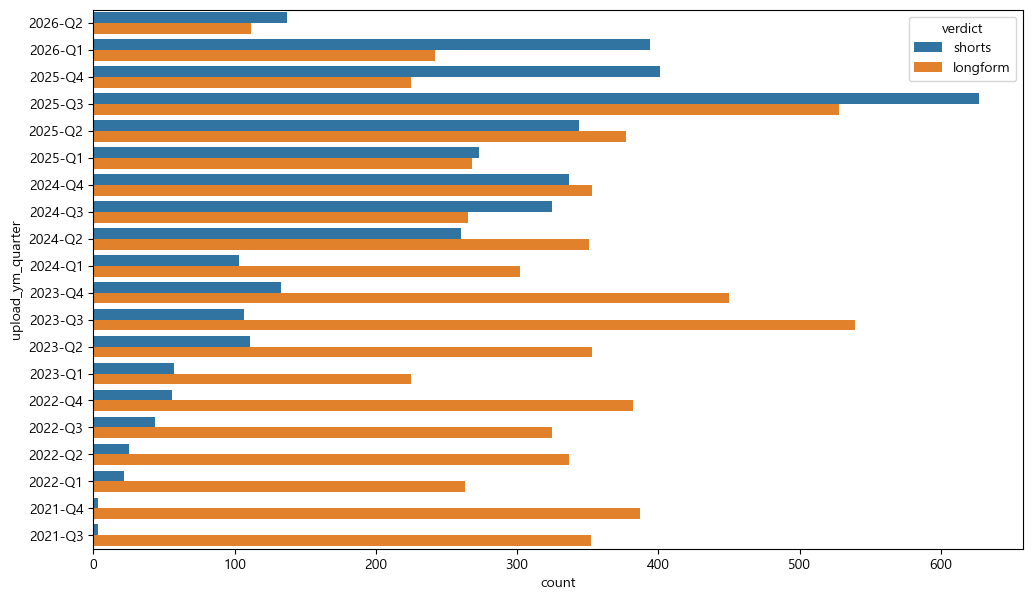

In [67]:
# 카테고리 분포 확인
plt.figure(figsize=(12,7))
sns.countplot(data=it_normal, y='upload_ym_quarter',hue='verdict')

<Axes: >

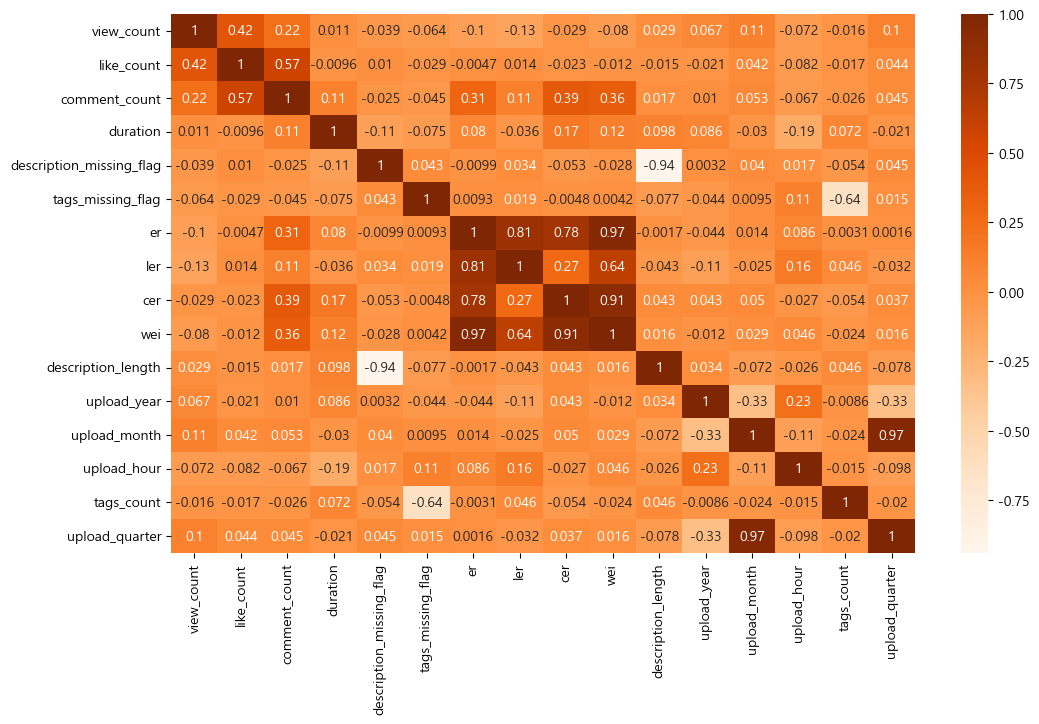

In [68]:
it_shorts_num = it_shorts.select_dtypes(include='number').columns.to_list()
it_shorts_num.remove('category_id')

corr = it_shorts[it_shorts_num].corr()
plt.figure(figsize=(12,7))
sns.heatmap(corr, cmap='Oranges', annot=True)



In [73]:
it_shorts['upload_ym_quarter'] = (
    it_shorts['upload_date'].dt.year.astype(str) + '-Q' +
    it_shorts['upload_date'].dt.quarter.astype(str)
)

quarterly_er = (
    it_shorts.groupby('upload_ym_quarter')['er']
    .mean()
    .reset_index()
    .rename(columns={'upload_ym_quarter': '분기', 'er': 'ER평균'})
    .sort_values('분기')
)

print(quarterly_er)

         분기      ER평균
0   2021-Q3  0.835870
1   2021-Q4  0.141966
2   2022-Q1  2.022958
3   2022-Q2  2.261150
4   2022-Q3  0.937411
5   2022-Q4  1.585880
6   2023-Q1  0.953022
7   2023-Q2  0.877015
8   2023-Q3  1.483819
9   2023-Q4  1.085624
10  2024-Q1  1.661687
11  2024-Q2  1.463757
12  2024-Q3  1.426440
13  2024-Q4  1.531472
14  2025-Q1  1.845413
15  2025-Q2  0.785854
16  2025-Q3  1.780220
17  2025-Q4  0.835314
18  2026-Q1  0.969605
19  2026-Q2  0.872506


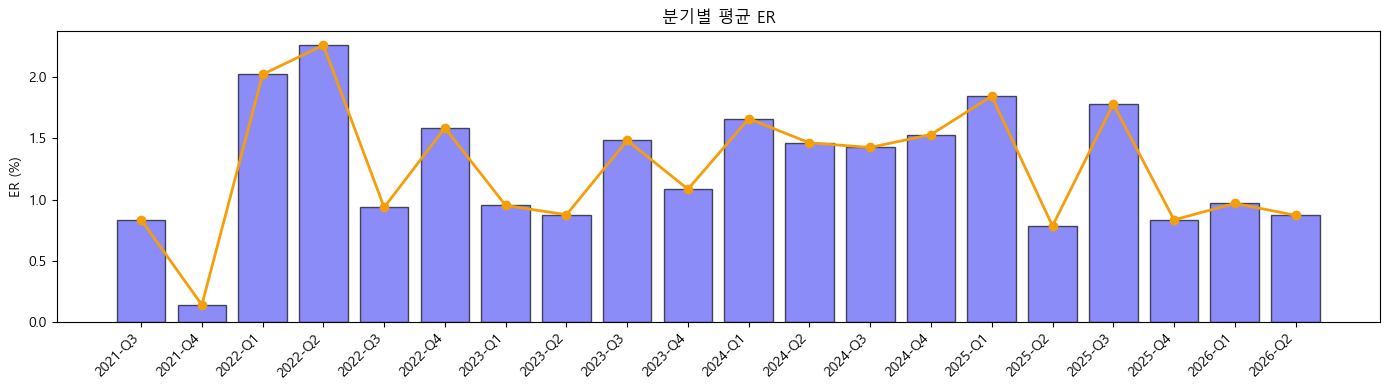

In [74]:
plt.figure(figsize=(14, 4))
plt.bar(quarterly_er['분기'], quarterly_er['ER평균'],
        color='#5b5bf6', alpha=0.7, edgecolor='#0a0a10')
plt.plot(quarterly_er['분기'], quarterly_er['ER평균'],
         color='#f59e0b', linewidth=2, marker='o', markersize=6)
plt.xticks(rotation=45, ha='right')
plt.title('분기별 평균 ER')
plt.ylabel('ER (%)')
plt.tight_layout()
plt.show()